# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué responidó (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | | | | | | |
| **Parte 2** | | | | | | |
| **Parte 3** | | | | | | |
| **Parte 4** | | | | | | |
| **Parte 5** | | | | | | |

Instale playwright en base a los recursos que elegí para el trabajo práctico.

In [1]:
!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-gradio 0.3.0 requires gradio-client<3.0,>=2.0, but you have gradio-client 1.4.0 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Playwright

In [2]:
!pip install playwright
!playwright install chromium


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports

In [1]:
from typing import Optional, Dict, List
from urllib.parse import urlparse
import sys
import os
import asyncio
import json

import nest_asyncio

if sys.platform == "win32":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

nest_asyncio.apply()

import spacy
import pandas as pd
import trafilatura
import whisper
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
from playwright.async_api import async_playwright, TimeoutError as PlaywrightTimeoutError

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# MARCO TEÓRICO E HIPÓTESIS

## Pregunta de Investigación
¿Cómo construyen los medios argentinos (Clarín, La Nación, Página 12) el discurso sobre IA y trabajo?

## Hipótesis Principal
El discurso mediático está estructurado por **vulnerabilidad laboral**:
1. IA como agente de **automatización y reemplazo**
2. Agencia concentrada en **empresas tech** (OpenAI, Anthropic, Google)
3. **Sindicatos ausentes** del discurso

## Subhipótesis
- **Verbos**: destructivos ("reemplazar", "eliminar") >> constructivos ("crear", "capacitar")
- **Entidades**: empresas tech como AGENTE >> trabajadores como AGENTE
- **Medios**: Infobea (catastrofista) ≠ La Nación (regulatorio) ≠ Clarín (oportunidad)

## Mediremos con spaCy
1. Frecuencia de verbos por categoría
2. Actores principales (quién hace qué)
3. Palabras clave por medio (TF-IDF)
4. Diferencias entre medios

## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

Elegí columnas mínimas titulo_o_fuente, texto y origen para unificar las tres fuentes (web, audio y JSON) en un esquema consistente. Los campos inexistentes en alguna fuente se completan con None para no perder filas ni forzar datos que no corresponden. Tambien decidi para las noticias que elegi usar playwright porque estan hechas con componentes dinamicos entonces trafilatura se queda corto para realizar el scraping

In [2]:
MAX_CONCURRENT = 3

def _extraer_medio(url: str) -> str:
    host = urlparse(url).netloc
    if 'lanacion.com.ar' in host:
        return 'La Nación'
    elif 'clarin.com' in host:
        return 'Clarín'
    elif 'pagina12.com.ar' in host:
        return 'Página 12'
    return 'Otro'


async def _extraer_url_async(url: str, page) -> Optional[Dict]:
    for intento in range(1, 4):
        try:
            await page.goto(url, timeout=20000, wait_until='domcontentloaded')
            try:
                await page.wait_for_load_state('networkidle', timeout=15000)
            except PlaywrightTimeoutError:
                pass

            for selector in [
                'button:has-text("Aceptar")',
                'button:has-text("Aceptar todo")',
                'button:has-text("Acepto")',
                'button:has-text("OK")',
                'button:has-text("Cerrar")',
                '[id*="cookie"] button',
                '[class*="cookie"] button',
                '[class*="consent"] button',
            ]:
                try:
                    await page.click(selector, timeout=2000)
                    await asyncio.sleep(1)
                    break
                except:
                    pass

            html = await page.content()

            extracted = trafilatura.extract(html, output_format='json', include_comments=False)
            if not extracted:
                continue

            if isinstance(extracted, str):
                extracted = json.loads(extracted)
            elif not isinstance(extracted, dict):
                continue

            titulo = extracted.get('title') or extracted.get('headline') or url.split('/')[-2]
            texto  = extracted.get('raw_text') or extracted.get('text')

            if texto and len(texto.strip()) > 200:
                return {
                    'titulo_o_fuente': titulo,
                    'texto': texto,
                    'medio': _extraer_medio(url),
                    'url_original': url,
                    'origen': 'web',
                }

        except PlaywrightTimeoutError as e:
            print(f"  [intento {intento}] Timeout: {e}")
        except json.JSONDecodeError as e:
            print(f"  [intento {intento}] JSON inválido: {e}")
        except Exception as e:
            print(f"  [intento {intento}] Error inesperado ({type(e).__name__}): {e}")

    return None

async def extraer_noticias_web_async(urls: List[str]) -> List[Dict]:
    sem = asyncio.Semaphore(MAX_CONCURRENT)
    noticias = []

async def extraer_noticias_web_async(urls: List[str]) -> List[Dict]:
    sem = asyncio.Semaphore(MAX_CONCURRENT)
    noticias = []

    async with async_playwright() as p:
        browser = await p.chromium.launch(
            headless=False,
            args=[
                '--disable-blink-features=AutomationControlled',
                '--no-sandbox',
            ]
        )
        context = await browser.new_context(
            user_agent=(
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/123.0.0.0 Safari/537.36"
            ),
            viewport={"width": 1280, "height": 800},
            locale="es-AR",
        )

        async def procesar_url(url: str):
            async with sem:
                print(f"Procesando: {url}...", end=" ", flush=True)
                page = await context.new_page()
                await page.add_init_script(
                    "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})"
                )
                try:
                    resultado = await _extraer_url_async(url, page)
                finally:
                    await page.close()
                await asyncio.sleep(2)

                if resultado:
                    noticias.append(resultado)
                    print("OK")
                else:
                    print("FALLO")

        await asyncio.gather(*[procesar_url(url) for url in urls])
        await context.close()
        await browser.close()

    return noticias


def extraer_noticias_web(urls: List[str]) -> List[Dict]:
    import threading
    resultado = []
    error = []

    def run():
        loop = asyncio.ProactorEventLoop()
        asyncio.set_event_loop(loop)
        try:
            resultado.extend(loop.run_until_complete(extraer_noticias_web_async(urls)))
        except Exception as e:
            error.append(e)
        finally:
            loop.close()

    t = threading.Thread(target=run)
    t.start()
    t.join()

    if error:
        raise error[0]
    return resultado

In [3]:
def transcribir_audio_youtube(url_video: str) -> List[Dict]:
    import yt_dlp
    archivo_audio = None
    try:
        ydl_opts = {
            'format': 'bestaudio[ext=m4a]/bestaudio',
            'outtmpl': 'audio_temp.%(ext)s',
            'quiet': True,
        }
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(url_video, download=True)
            titulo = info['title']
            ext = info.get('ext', 'm4a')
            archivo_audio = f"audio_temp.{ext}"
            print(f"Video descargado: {titulo}")

        model = whisper.load_model('base', device='cpu')
        result = model.transcribe(archivo_audio, language='es')

        return [{
            'titulo_o_fuente': titulo,
            'texto': result['text'],
            'medio': 'YouTube',
            'url_original': url_video,
            'origen': 'audio',
        }]

    except Exception as e:
        print(f"Error al transcribir: {e}")
        return []

    finally:
        if archivo_audio and os.path.exists(archivo_audio):
            os.remove(archivo_audio)
            print(f"Archivo temporal eliminado: {archivo_audio}")

In [4]:
def cargar_json_previo(ruta_json: str) -> List[Dict]:
    try:
        with open(ruta_json, 'r', encoding='utf-8') as f:
            datos = json.load(f)
        if isinstance(datos, list):
            return datos
        print(f"Formato inesperado: se esperaba lista, se encontró {type(datos).__name__}")
        return []
    except FileNotFoundError:
        print(f"Archivo no encontrado: {ruta_json}")
        return []
    except json.JSONDecodeError as e:
        print(f"Error al parsear JSON '{ruta_json}': {e}")
        return []


In [5]:
def unificar_corpus(datos_web, datos_audio, datos_json) -> pd.DataFrame:
    todos = datos_web + datos_audio + datos_json
    df = pd.DataFrame(todos)
    columnas = ['titulo_o_fuente', 'texto', 'medio', 'url_original', 'origen']
    for col in columnas:
        if col not in df.columns:
            df[col] = None
    return df[columnas]

urls_noticias = [
    "https://www.pagina12.com.ar/810645-cambios-en-el-trabajo",
    "https://www.lanacion.com.ar/economia/IA/las-diez-profesiones-mas-expuestas-a-la-inteligencia-artificial-segun-anthropic-nid10032026/",
    "https://www.clarin.com/cultura/cecilia-rikap-ia-negocio-pocas-empresas-profundiza-desigualdad-laboral_0_l8rEJbBdg5.html",
    "https://www.pagina12.com.ar/797285-buscar-trabajo-en-la-era-de-la-inteligencia-artificial-entre/",
]

datos_web   = extraer_noticias_web(urls_noticias)
datos_audio = transcribir_audio_youtube("https://www.youtube.com/watch?v=xnNvTwlFZRM")
datos_json  = []

df_corpus = unificar_corpus(datos_web, datos_audio, datos_json)
print(f"Corpus unificado: {len(df_corpus)} documentos")
print(df_corpus.head())

Procesando: https://www.pagina12.com.ar/810645-cambios-en-el-trabajo... Procesando: https://www.lanacion.com.ar/economia/IA/las-diez-profesiones-mas-expuestas-a-la-inteligencia-artificial-segun-anthropic-nid10032026/... Procesando: https://www.clarin.com/cultura/cecilia-rikap-ia-negocio-pocas-empresas-profundiza-desigualdad-laboral_0_l8rEJbBdg5.html... OK
Procesando: https://www.pagina12.com.ar/797285-buscar-trabajo-en-la-era-de-la-inteligencia-artificial-entre/... OK
OK
OK


Video descargado: ¿La inteligencia artificial te dejará sin trabajo? | Federico Pascual | TEDxDurazno


c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Archivo temporal eliminado: audio_temp.m4a
Corpus unificado: 5 documentos
                                     titulo_o_fuente  \
0                                            cultura   
1  las-diez-profesiones-mas-expuestas-a-la-inteli...   
2                                www.pagina12.com.ar   
3  797285-buscar-trabajo-en-la-era-de-la-intelige...   
4  ¿La inteligencia artificial te dejará sin trab...   

                                               texto      medio  \
0  - Comentar\nUna economista que no solo no cae ...     Clarín   
1  Una reciente investigación de la compañía seña...  La Nación   
2  El 55 por ciento de los trabajadores ya incorp...  Página 12   
3  Que el mercado laboral cambió en los últimos a...  Página 12   
4   Hola, mi nombre es Federico Pajuel y trabajo ...    YouTube   

                                        url_original origen  
0  https://www.clarin.com/cultura/cecilia-rikap-i...    web  
1  https://www.lanacion.com.ar/economia/IA/las-di...    web  


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

## Auditoría del DataFrame consolidado

Al ejecutar `df_corpus.head()` se observan 5 documentos provenientes de
4 fuentes distintas: La Nación, Clarín, Página 12 (2 artículos) y YouTube.

### Impacto de Whisper vs. texto estructurado

La transcripción del TED Talk (doc 4) presenta diferencias notables respecto
a los artículos periodísticos:

- **Sin puntuación**: Whisper no agrega puntos, comas ni signos de pregunta
  de forma confiable, lo que afecta la segmentación de oraciones en spaCy.
  El tokenizador puede fusionar oraciones o dividirlas incorrectamente.
- **Marcas de oralidad**: aparecen muletillas, reformulaciones y frases
  incompletas ("Hola, mi nombre es Federico Pajuel y trabajo...") que no
  existen en texto periodístico. Esto introduce ruido en el análisis de
  verbos y entidades.
- **Sin párrafos**: el texto es un bloque continuo, mientras que los
  artículos tienen estructura de título, lead y cuerpo.

### Columnas generadas

Las 5 columnas esperadas están presentes en todos los documentos:
`titulo_o_fuente`, `texto`, `medio`, `url_original`, `origen`.
No se perdió información contextual al unificar porque `unificar_corpus()`
rellena con `None` las columnas faltantes.

### Información contextual perdida

Se perdió el **autor**, la **fecha de publicación** y la **sección** de cada
artículo, ya que el esquema de columnas no los contempla. Esto limita análisis
diacrónicos o por autoría, pero no afecta el análisis lingüístico del TP.

## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [6]:
class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_lg"):
        self.df = df.copy()
        print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)
        print("Procesando los textos con spaCy...")
        self.df['doc'] = self.df['texto'].apply(
            lambda t: self.nlp(t) if isinstance(t, str) else self.nlp("")
        )
        print(f"Procesados {len(self.df)} documentos.")

    def extraer_entidades(self) -> Dict[str, Counter]:
        entidades: Dict[str, Counter] = {}
        for doc in self.df['doc']:
            for ent in doc.ents:
                if ent.label_ not in entidades:
                    entidades[ent.label_] = Counter()
                entidades[ent.label_][ent.text] += 1
        return entidades

    def extraer_verbos_principales(self, n: int = 15) -> List[tuple]:
        verbos: Counter = Counter()
        for doc in self.df['doc']:
            for token in doc:
                if token.pos_ == 'VERB' and not token.is_stop and token.is_alpha and len(token.lemma_) > 2:
                    verbos[token.lemma_.lower()] += 1
        return verbos.most_common(n)

    def extraer_palabras_clave(self, n: int = 20) -> List[tuple]:
        palabras: Counter = Counter()
        for doc in self.df['doc']:
            for token in doc:
                if token.pos_ in ('NOUN', 'PROPN') and not token.is_stop and token.is_alpha and len(token.lemma_) > 2:
                    palabras[token.lemma_.lower()] += 1
        return palabras.most_common(n)

    def estadisticas_corpus(self) -> Dict:
        total_tokens = 0
        lemas_unicos: set = set()
        total_oraciones = 0
        for doc in self.df['doc']:
            total_tokens += len(doc)
            total_oraciones += len(list(doc.sents))
            lemas_unicos.update(t.lemma_.lower() for t in doc if t.is_alpha)
        return {
            'total_documentos': len(self.df),
            'total_tokens': total_tokens,
            'vocabulario_unico': len(lemas_unicos),
            'total_oraciones': total_oraciones,
            'medios': self.df['medio'].value_counts().to_dict(),
        }

analizador = AnalizadorCorpus(df_corpus)
print(analizador.estadisticas_corpus())

Cargando modelo de lenguaje...
Procesando los textos con spaCy...
Procesados 5 documentos.
{'total_documentos': 5, 'total_tokens': 7829, 'vocabulario_unico': 1453, 'total_oraciones': 262, 'medios': {'Página 12': 2, 'Clarín': 1, 'La Nación': 1, 'YouTube': 1}}


In [7]:
doc_noticia = analizador.df[analizador.df['origen'] == 'web']['doc'].iloc[0]
doc_audio   = analizador.df[analizador.df['origen'] == 'audio']['doc'].iloc[0]

print("=== NOTICIA - primeras 5 oraciones ===")
for sent in list(doc_noticia.sents)[:5]:
    print(repr(sent.text))

print("\n=== AUDIO - primeras 5 oraciones ===")
for sent in list(doc_audio.sents)[:5]:
    print(repr(sent.text))

print("\n=== NOTICIA - primeras 10 entidades ===")
print([(e.text, e.label_) for e in doc_noticia.ents[:10]])

print("\n=== AUDIO - primeras 10 entidades ===")
print([(e.text, e.label_) for e in doc_audio.ents[:10]])

=== NOTICIA - primeras 5 oraciones ===
'- Comentar\nUna economista que no solo no cae en la idolatría de la Inteligencia Artificial Generativa (IAG) sino que además toma mucha distancia de ella y expone los intereses políticos y económicos de las megaempresas que empujan a la sociedad a enredarse y depender de esos productos.'
'Esa podría ser una línea entre otras para presentar a Cecilia Rikap, argentina, nacida en 1984, formada en la UBA y actualmente profesora asociada de Economia y jefa de Investigación del Instituto de Innovación y Propósito Público del University College, de Londres.'
'Ella, investigadora del Conicet y del laboratorio COSTECH de la Université de la Tecnhologie de Compiégne, Francia, es la autora de Teoría de la Dependencia Digital.'
'Soberanía y desarrollo en el capitalismo del siglo XXI, publicado recientemente por Caja Negra y del que todos están hablando.\n'
'Un mediodía húmedo y una habitación de paredes blancas con piso de madera en el espacio que comparten 

> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

## Auditoría: spaCy sobre noticia escrita vs. transcripción Whisper

### Segmentación de oraciones (sents)

**Noticia escrita:** spaCy segmenta correctamente — cada oración tiene
estructura gramatical clara, con sujeto, verbo y punto final. El modelo
identifica bien los límites oracionales.

**Audio transcripto:** La primera "oración" es un espacio en blanco `' '`.
Las siguientes son bloques largos sin puntuación interna, mezclando ideas
que deberían ser oraciones separadas. spaCy no puede dividirlas correctamente
porque Whisper no genera puntos entre frases.

### Detección de entidades (NER)

**Noticia escrita — errores detectados:**
- `Anthropic` clasificado como `LOC` (lugar) en vez de `ORG` (organización)
- `Claude` clasificado como `PER` (persona) en vez de producto/ORG
- `Sin embargo` y oraciones completas clasificadas como `MISC`

**Audio transcripto — errores más graves:**
- `Trilados` (nombre mal transcripto de "Tryolabs") → `MISC`
- `Pro de Ago Distinto` (error de transcripción) → `MISC`
- `La idea de Estachala` (error de transcripción) → `MISC`
- Oraciones enteras clasificadas como entidades

### ¿Por qué ocurre esto?

En el audio, Whisper comete errores de transcripción ("Pajuel" por "Pascual",
"Trilados" por "Tryolabs", "Estachala" por "esta charla") porque el modelo
fonético confunde palabras poco frecuentes. Esos errores se propagan a spaCy,
que nunca vio esas "palabras" en su entrenamiento y las clasifica como
entidades desconocidas de tipo MISC.

En la noticia escrita los errores son menores pero igual existen: spaCy
confunde organizaciones con lugares (Anthropic → LOC) porque fue entrenado
con textos donde esos nombres no aparecían frecuentemente como ORG.

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

Para un informe dirigido a toma de decisiones, el **Barplot** es superior
al WordCloud aplicando el principio de Data-Ink Ratio de Edward Tufte.

**WordCloud:** cada palabra ocupa un área proporcional a su frecuencia, pero
la percepción humana del área es imprecisa — es difícil determinar si una
palabra aparece 50 o 80 veces. Además, la posición y el color no codifican
ningún dato, son puramente decorativos. Alta proporción de "tinta sin datos".

**Barplot horizontal:** cada barra tiene una longitud exactamente proporcional
a la frecuencia. El ojo humano compara longitudes con mucha más precisión que
áreas. Permite ordenar de mayor a menor, leer etiquetas claramente y extraer
conclusiones en segundos. Toda la tinta comunica un dato.

**Conclusión:** elegimos el Lollipop Chart (variante del barplot) implementado
en `visualizar_palabras_clave_lollipop()` porque maximiza el Data-Ink Ratio —
usa una línea fina como palo y un punto como cabeza, reduciendo la tinta
decorativa al mínimo sin perder legibilidad. Es la opción correcta para
comunicar frecuencias a quienes toman decisiones.

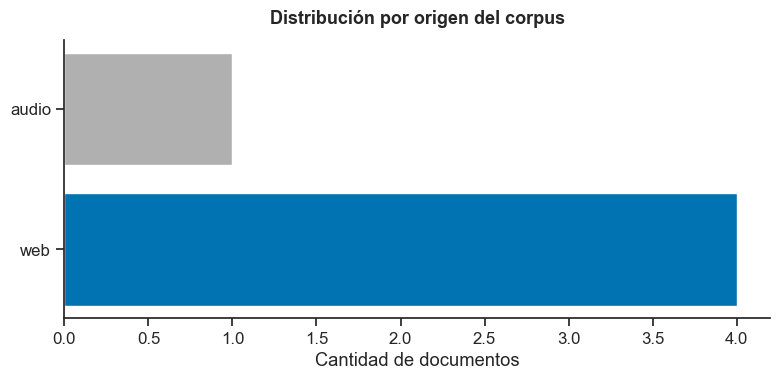

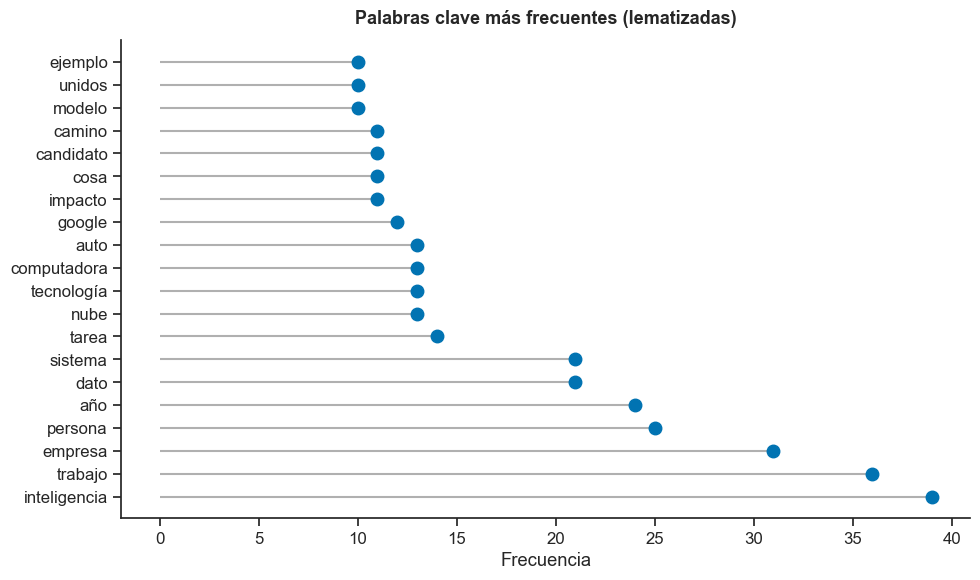

In [8]:
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE   = '#b0b0b0'


def visualizar_origen(df: pd.DataFrame):
    conteo = df['origen'].value_counts()
    colores = [COLOR_ACENTO if i == 0 else COLOR_BASE for i in range(len(conteo))]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(conteo.index, conteo.values, color=colores)
    ax.set_title('Distribución por origen del corpus', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Cantidad de documentos')
    ax.set_ylabel('')
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig


def visualizar_palabras_clave_lollipop(palabras_clave: List[tuple]):
    if not palabras_clave:
        return None
    palabras, frecuencias = zip(*palabras_clave)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hlines(y=range(len(palabras)), xmin=0, xmax=frecuencias, color=COLOR_BASE, linewidth=1.5)
    ax.plot(frecuencias, range(len(palabras)), 'o', color=COLOR_ACENTO, markersize=9)
    ax.set_yticks(range(len(palabras)))
    ax.set_yticklabels(palabras)
    ax.set_title('Palabras clave más frecuentes (lematizadas)', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Frecuencia')
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig


def visualizar_entidades_plotly(entidades_dict: Dict[str, Counter]):
    categorias = ['PER', 'ORG', 'LOC', 'MISC']
    fig = go.Figure()
    for cat in categorias:
        if cat not in entidades_dict:
            continue
        top = entidades_dict[cat].most_common(10)
        if not top:
            continue
        nombres, counts = zip(*top)
        fig.add_trace(go.Bar(name=cat, x=list(nombres), y=list(counts)))
    fig.update_layout(
        barmode='group',
        title='Entidades nombradas por categoría (top 10 cada una)',
        xaxis_title='Entidad',
        yaxis_title='Frecuencia',
        template='plotly_white',
        legend_title='Tipo',
        font=dict(size=12),
    )
    return fig

# Prueba rápida
visualizar_origen(df_corpus)
visualizar_palabras_clave_lollipop(analizador.extraer_palabras_clave())
visualizar_entidades_plotly(analizador.extraer_entidades())

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [9]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web   = urls_web or []
        self.url_audio  = url_audio
        self.ruta_json  = ruta_json
        self.df         = None
        self.analizador = None

    def ejecutar_pipeline(self):
        datos_web   = extraer_noticias_web(self.urls_web) if self.urls_web else []
        datos_audio = transcribir_audio_youtube(self.url_audio) if self.url_audio else []
        datos_json  = cargar_json_previo(self.ruta_json) if self.ruta_json else []
        self.df = unificar_corpus(datos_web, datos_audio, datos_json)
        print(f"Corpus: {len(self.df)} documentos.")
        self.analizador = AnalizadorCorpus(self.df)
        print("Pipeline ejecutado exitosamente.")

    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json_out="estadisticas.json"):
        if self.df is None or self.analizador is None:
            print("Primero ejecutá ejecutar_pipeline().")
            return
        df_export = self.df.drop(columns=['doc'], errors='ignore')
        df_export.to_csv(ruta_csv, index=False, encoding='utf-8')
        print(f"CSV exportado → {ruta_csv}")
        stats = self.analizador.estadisticas_corpus()
        entidades = self.analizador.extraer_entidades()
        reporte = {
            'estadisticas': stats,
            'entidades_top': {k: dict(v.most_common(10)) for k, v in entidades.items()},
            'verbos_top': dict(self.analizador.extraer_verbos_principales()),
            'palabras_clave_top': dict(self.analizador.extraer_palabras_clave()),
        }
        with open(ruta_json_out, 'w', encoding='utf-8') as f:
            json.dump(reporte, f, ensure_ascii=False, indent=2)
        print(f"JSON exportado → {ruta_json_out}")

> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [14]:
!pip install "jinja2<3.1"

  Attempting uninstall: jinja2
    Found existing installation: Jinja2 3.1.6
    Uninstalling Jinja2-3.1.6:
      Successfully uninstalled Jinja2-3.1.6



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
pipeline = PipelineMediatico(urls_web=urls_noticias)

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("#  Explorador de Agenda Mediática")
    gr.Markdown("Analizá el discurso sobre IA y trabajo en medios argentinos.")

    with gr.Tab("Panorama y Métricas"):
        btn_cargar = gr.Button("▶ Ejecutar pipeline y cargar análisis", variant="primary")
        plot_origen = gr.Plot(label="Origen del corpus")
        plot_palabras = gr.Plot(label="Palabras clave")
        metricas_df = gr.DataFrame(label="Estadísticas generales del corpus")

        def cargar_metricas():
            pipeline.ejecutar_pipeline()
            fig_origen = visualizar_origen(pipeline.df)
            fig_palabras = visualizar_palabras_clave_lollipop(pipeline.analizador.extraer_palabras_clave())
            stats = pipeline.analizador.estadisticas_corpus()
            stats_plano = {
                'total_documentos': stats['total_documentos'],
                'total_tokens': stats['total_tokens'],
                'vocabulario_unico': stats['vocabulario_unico'],
                'total_oraciones': stats['total_oraciones'],
            }
            for medio, cant in stats['medios'].items():
                stats_plano[f'medio_{medio}'] = cant
            df_stats = pd.DataFrame([stats_plano])
            return fig_origen, fig_palabras, df_stats

        btn_cargar.click(fn=cargar_metricas, inputs=[], outputs=[plot_origen, plot_palabras, metricas_df])

    with gr.Tab("Explorador de Entidades"):
        gr.Markdown("Ingresá una entidad para ver las oraciones del corpus donde aparece.")
        entidad_input = gr.Textbox(label="Entidad a buscar", placeholder="Ej: OpenAI, sindicato...")
        btn_buscar = gr.Button(" Buscar")
        resultados_text = gr.Textbox(label="Oraciones encontradas", lines=15, interactive=False)

        def buscar_entidad(texto_entidad):
            if pipeline.analizador is None:
                return "Primero ejecutá el pipeline desde la pestaña anterior."
            if not texto_entidad.strip():
                return "Ingresá una entidad para buscar."
            resultados = []
            for i, row in pipeline.analizador.df.iterrows():
                doc = pipeline.analizador.df.loc[i, 'doc']
                for sent in doc.sents:
                    if texto_entidad.lower() in sent.text.lower():
                        resultados.append(f"[{row['medio']}] {sent.text.strip()}")
            return "\n\n".join(resultados[:20]) if resultados else f"No se encontró '{texto_entidad}'"

        btn_buscar.click(fn=buscar_entidad, inputs=entidad_input, outputs=resultados_text)

dashboard_medios.launch(share=True)

Running on local URL:  http://127.0.0.1:7869


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\uvicorn\protocols\http\h11_impl.py", line 406, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        self.scope, self.receive, self.send
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\uvicorn\middleware\proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\fastapi\applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\starlette\applications.py", line 90, in __call__
    await se


Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\uvicorn\protocols\http\h11_impl.py", line 406, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        self.scope, self.receive, self.send
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\uvicorn\middleware\proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\fastapi\applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\starlette\applications.py", line 90, in __call__
    await se

---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.